<a href="https://colab.research.google.com/github/Broklink/Data-test/blob/main/Copy_of_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [98]:
import warnings
import statsmodels

# ADD THIS TO THE TOP OF YOUR SCRIPT:
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module='statsmodels'
)

## Data Gathering

In [99]:
# Connect to GoogleDrive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
# Read a file from GoogleDrive.
file_path = '/content/drive/MyDrive/Colab Notebooks/goldstock.csv'
df = pd.read_csv(file_path)

In [101]:
# Display the first 5 rows to get a quick look at the data structure.
df.head()

,Unnamed: 0,Date,Close,Volume,Open,High,Low
0,0,2024-01-19,2029.3,166078.0,2027.4,2041.9,2022.2
1,1,2024-01-18,2021.6,167013.0,2009.1,2025.6,2007.7
2,2,2024-01-17,2006.5,245194.0,2031.7,2036.1,2004.6
3,3,2024-01-16,2030.2,277995.0,2053.4,2062.8,2027.6
4,4,2024-01-12,2051.6,250946.0,2033.2,2067.3,2033.1


In [102]:
# Check total length of dataset.
len(df)

2511

In [103]:
# Check for data type in each column.
df.dtypes

,0
Unnamed: 0,int64
Date,object
Close,float64
Volume,float64
Open,float64
High,float64
Low,float64


In [104]:
# Define target.
label = 'Close'

In [105]:
# Define timestamp column.
ts = 'Date'

## Data Preprocessing

### Universal Data Cleaning

#### Clean Date Type

In [106]:
# Change timestamp column from string to datetime.
df[ts] = pd.to_datetime(df[ts], format="%Y-%m-%d")

In [107]:
# Check for data type again.
df.dtypes

,0
Unnamed: 0,int64
Date,datetime64[ns]
Close,float64
Volume,float64
Open,float64
High,float64
Low,float64


#### Select Observation

In [108]:
# Set Timestamp Index
df.index = df[ts]

In [109]:
# Select observation column.
df = df[[label]]

#### Duplicate Data

In [110]:
# Check duplicate index.
df[df.index.duplicated(keep=False)]

,Close
Date,
2021-11-23,1786.3
2021-11-22,1809.1
2021-11-19,1854.3
2021-11-18,1864.0
2021-11-17,1872.8
2021-11-16,1854.1
2021-11-15,1866.6
2021-11-12,1868.5
2021-11-11,1863.9


#### Missing Data

In [111]:
# Check for missing values in each column.
df.isnull().sum()

,0
Close,0


#### Check Timestamp Diff

In [116]:
# Check timestamp diff.
df.index.diff().value_counts()

,count
Date,
-1 days,1964
-3 days,450
-4 days,72
-2 days,21
-5 days,1
25 days,1
-25 days,1


#### Fix Missing Timestamp

In [119]:
# ลบ duplicate index
df = df[~df.index.duplicated(keep='first')]

# สร้าง full index รายวัน
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Reindex df ให้ตรงกับ full_index
df = df.reindex(full_index)

# เติมค่า missing ด้วย linear interpolation
df['Close'] = df['Close'].interpolate()


In [120]:
# Check for missing values after reindex.
df.isnull().sum()

,0
Close,0


In [121]:
# Fix missing data
df[label] = df[label].interpolate(method='linear')

In [122]:
# Check for missing values after fill missing data.
df.isnull().sum()

,0
Close,0


### Data Exploration

Rolling Observation

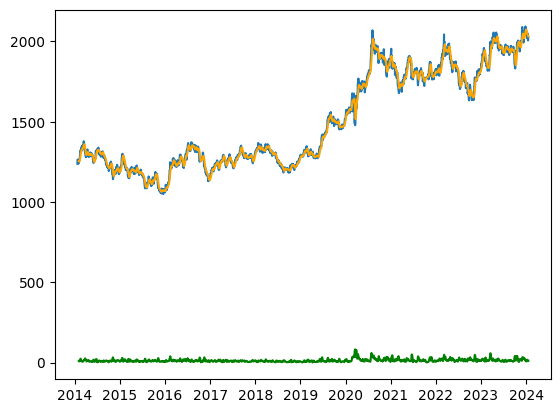

In [132]:
# Plot observation.
plt.plot(df.index, df[label])
# Plot rolling mean of observation for 12 months.
plt.plot(df.index, df[label].rolling(window=12).mean(), color='orange')
# Plot rolling std of observation for 24 hours * 7 days.
plt.plot(df.index, df[label].rolling(window=12).std(), color='green')
plt.show()

Component

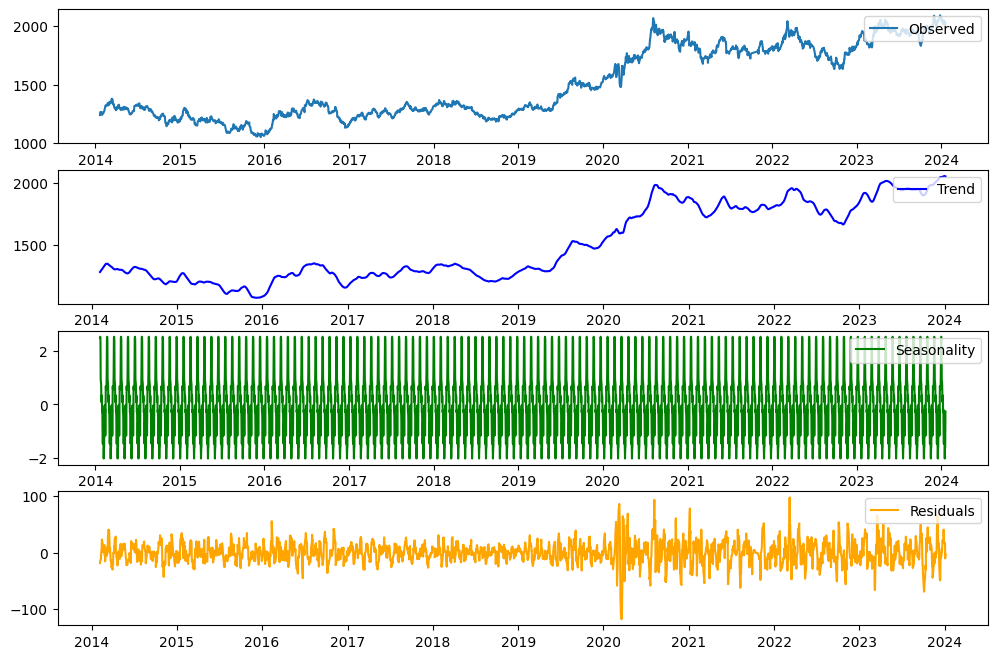

In [124]:
# Create decomposition.
decomposition = seasonal_decompose(df, model='additive', period=30)


plt.figure(figsize=(12, 8))

# Plot observation.
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper right')

# Plot trend component.
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='blue')
plt.legend(loc='upper right')

# Plot seasonal component.
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.legend(loc='upper right')

# Plot residual component.
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='orange')
plt.legend(loc='upper right')

plt.show()

Autocorrelation

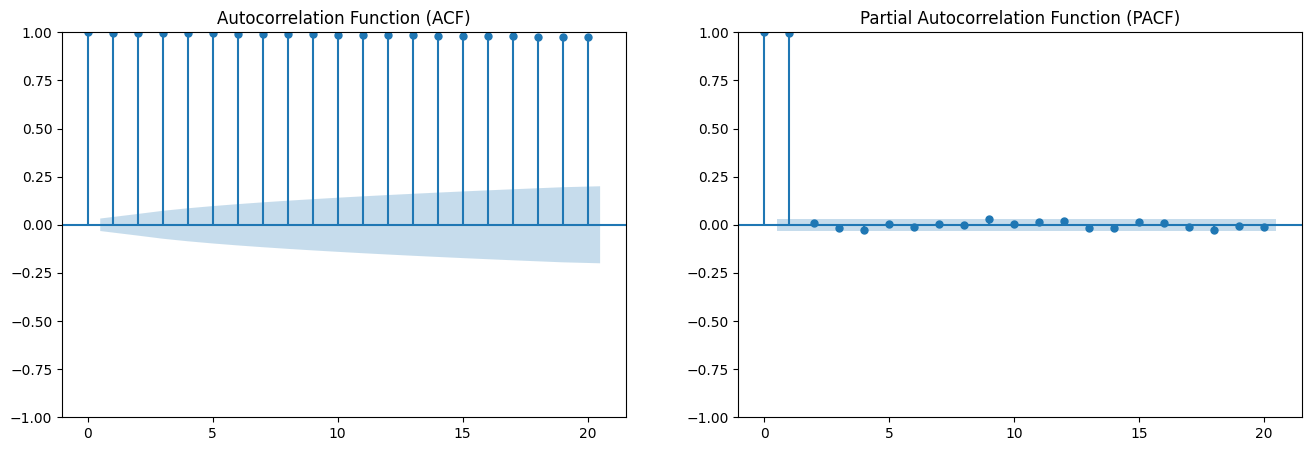

In [125]:
# Create subplot.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF.
plot_acf(df[label], lags=20, ax=axes[0], title='Autocorrelation Function (ACF)')

# Plot PACF.
plot_pacf(df[label], lags=20, ax=axes[1], title='Partial Autocorrelation Function (PACF)')

plt.show()

### Data Splitting

In [126]:
# Define ratio of each dataset.
train_ratio = 0.7

# Set end point of each data set.
train_end = int(len(df) * train_ratio)

# Split data.
train_data = df[label].iloc[:train_end]
test_data = df[label].iloc[train_end:]

In [127]:
# Check training set.
train_data

,Close
2014-01-22,1238.600000
2014-01-23,1262.500000
2014-01-24,1264.500000
2014-01-25,1264.166667
2014-01-26,1263.833333
...,...
2021-01-15,1829.900000
2021-01-16,1832.475000
2021-01-17,1835.050000
2021-01-18,1837.625000


In [128]:
# Check test set.
test_data

,Close
2021-01-20,1870.20
2021-01-21,1869.30
2021-01-22,1859.90
2021-01-23,1859.60
2021-01-24,1859.30
...,...
2024-01-15,2035.55
2024-01-16,2030.20
2024-01-17,2006.50
2024-01-18,2021.60


## Model Training

In [129]:
# Set look back period.
look_back = 36

# Set prediction step.
look_forward = 6

### Hyperparameter Tuning

In [137]:
# ช่วงค่า hyperparameter ของ ARIMA
p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)

min_mse = np.inf
best_order = None

print("Start Training ARIMA")
for p in p_range:
    for d in d_range:
        for q in q_range:
            order = (p, d, q)
            print(f"  Training order: {order}")

            mse_list = []
            for i in range(look_back, len(train_data) - look_forward):
                # ข้อมูล train input
                input_data = train_data.iloc[i - look_back:i]
                # ข้อมูล validation
                val_data = train_data.iloc[i:i + look_forward]

                val_start_index = val_data.index[0]
                val_end_index = val_data.index[-1]

                try:
                    # Fit ARIMA
                    model = ARIMA(input_data, order=order)
                    model_fit = model.fit()

                    # Forecast validation
                    pred_data = model_fit.predict(start=val_start_index, end=val_end_index)

                    # คำนวณ MSE
                    mse_list.append(mean_squared_error(val_data, pred_data))
                except:
                    # ถ้า fit ไม่ได้ข้ามไป
                    continue

            if mse_list:  # มีค่า MSE ถึงคำนวณได้
                mse = np.mean(mse_list)
                print(f"    MSE: {mse:.3f} | Min MSE: {min_mse:.3f}")

                if mse < min_mse:
                    min_mse = mse
                    best_order = order

print(f"Best ARIMA order: {best_order}")
print(f"Minimum MSE: {min_mse:.3f}")

Start Training ARIMA
  Training order: (0, 0, 0)
    MSE: 1481.666 | Min MSE: inf
  Training order: (0, 0, 1)
    MSE: 1339.103 | Min MSE: 1481.666
  Training order: (0, 0, 2)
    MSE: 1223.799 | Min MSE: 1339.103
  Training order: (0, 1, 0)
    MSE: 408.484 | Min MSE: 1223.799
  Training order: (0, 1, 1)
    MSE: 411.892 | Min MSE: 408.484
  Training order: (0, 1, 2)
    MSE: 428.287 | Min MSE: 408.484
  Training order: (1, 0, 0)
    MSE: 429.427 | Min MSE: 408.484
  Training order: (1, 0, 1)
    MSE: 434.284 | Min MSE: 408.484
  Training order: (1, 0, 2)
    MSE: 445.037 | Min MSE: 408.484
  Training order: (1, 1, 0)
    MSE: 413.957 | Min MSE: 408.484
  Training order: (1, 1, 1)
    MSE: 433.260 | Min MSE: 408.484
  Training order: (1, 1, 2)
    MSE: 450.156 | Min MSE: 408.484
  Training order: (2, 0, 0)
    MSE: 443.629 | Min MSE: 408.484
  Training order: (2, 0, 1)
    MSE: 526.131 | Min MSE: 408.484
  Training order: (2, 0, 2)
    MSE: 1089.593 | Min MSE: 408.484
  Training order

## Model Evaluation

Evaluate training set

In [138]:
# Create lists of metrics.
mae_list = []
mse_list = []
rmse_list = []
mape_list = []

# Predict training set.
for i in range(look_back, len(train_data) - look_forward):
  # Setup prediction range.
  input_data = train_data.iloc[i - look_back:i]
  eval_data = train_data.iloc[i:i + look_forward]
  eval_start_index = eval_data.index[0]
  eval_end_index = eval_data.index[-1]

  # Fit model on each evaluation period.
  model = ARIMA(input_data, order=best_order)
  model_fit = model.fit()

  # Forecast the evaluation period.
  pred_data = model_fit.predict(start=eval_start_index, end=eval_end_index)

  # Align indices for error calculation.
  pred_data.index = eval_data.index

  # Calculate mertics on each evaluation.
  mse_list.append(mean_squared_error(eval_data, pred_data))
  rmse_list.append(np.sqrt(mean_squared_error(eval_data, pred_data)))
  mae_list.append(mean_absolute_error(eval_data, pred_data))
  mape_list.append(np.mean(np.abs((eval_data - pred_data) / eval_data)) * 100)

# Average final metrics.
mse = np.mean(mse_list)
rmse = np.mean(rmse_list)
mae = np.mean(mae_list)
mape = np.mean(mape_list)


In [139]:
# Print results.
print(f"Mean: {train_data.mean():.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean: 1345.25
Mean Absolute Error (MAE): 13.30
Mean Absolute Percentage Error (MAPE): 0.97
Root Mean Squared Error (RMSE): 15.32


Evaluate test set

In [140]:
# Create lists of metrics.
mae_list = []
mape_list = []
mse_list = []
rmse_list = []

# Predict test set.
for i in range(look_back, len(test_data) - look_forward):
  # Setup prediction range.
  input_data = test_data.iloc[i - look_back:i]
  eval_data = test_data.iloc[i:i + look_forward]
  eval_start_index = eval_data.index[0]
  eval_end_index = eval_data.index[-1]

  # Fit model on each evaluation period.
  model = ARIMA(input_data, order=best_order)
  model_fit = model.fit()

  # Forecast the evaluation period.
  pred_data = model_fit.predict(start=eval_start_index, end=eval_end_index)

  # Align indices for error calculation.
  pred_data.index = eval_data.index

  # Calculate mertics on each evaluation.
  mse_list.append(mean_squared_error(eval_data, pred_data))
  rmse_list.append(np.sqrt(mean_squared_error(eval_data, pred_data)))
  mae_list.append(mean_absolute_error(eval_data, pred_data))
  mape_list.append(np.mean(np.abs((eval_data - pred_data) / eval_data)) * 100)

# Average final metrics.
mse = np.mean(mse_list)
rmse = np.mean(rmse_list)
mae = np.mean(mae_list)
mape = np.mean(mape_list)


In [141]:
# Print results.
print(f"Mean: {train_data.mean():.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean: 1345.25
Mean Absolute Error (MAE): 17.25
Mean Absolute Percentage Error (MAPE): 0.93
Root Mean Squared Error (RMSE): 19.88


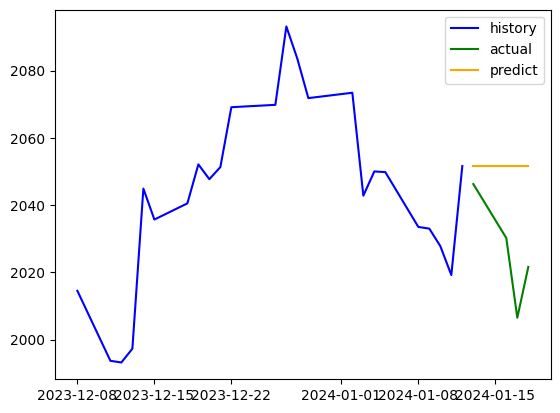

In [142]:
# Plot example trend prediction.
plt.plot(input_data.index, input_data.values, label='history', color='blue')
plt.plot(eval_data.index, eval_data.values, label='actual', color='green')
plt.plot(pred_data.index, pred_data.values, label='predict', color='orange')
plt.legend()
plt.show()